# The untightened and tightened seed boxes, side by side, on all 14 ROIs

Visual companion to `bbox_refinement_three_way_chromatin_od.ipynb`. That notebook measured
precision@K for three ways of cutting the seed template from the same click. This one shows, ROI
by ROI, exactly what each of those templates was:

| row | condition | how the box is made |
|---|---|---|
| 1 | `default_51` -- **untightened** | fixed 51 x 51 px box centred on the click, no Otsu step |
| 2 | `gray_bbox` -- tightened | Otsu on `gray_inverted` in the 51 px window, box = accepted component, recentred (D8) |
| 3 | `hem_bbox` -- tightened | the same on `hematoxylin_od` |

**The same 14 clicks as the measurement notebook.** Same RNG stream (`[0, image_id]`), same joint
gate (both Otsu gates must accept, every template readable). Step 1 checks the clicks, box sizes
and offsets against that run's saved CSV.

**What each per-ROI figure shows.**
1. The 51 px Otsu window in that row's channel, with the click at its centre.
2. The Otsu binary mask.
3. The connected components, with the component containing the click outlined.
4. The box on the H&E image in context (91 px around the click), with the click and the pixel the
   template is centred on.
5. The template as it looks (RGB crop).
6. The template as the matcher sees it: the `hematoxylin_od` array `find_and_suppress` actually
   correlates.

Panels 5 and 6 draw every template **at true scale inside a fixed 51 px frame**, so a 23 px
template looks half the size of a 51 px one. (The reference notebook stretched each template to
fill its panel, which hides the size difference.) `default_51` has no Otsu step, so its row has no
panels 1-3. Note that its box is exactly the 51 px window the two Otsu rows threshold.

**How exact the pictures are.**
- *Otsu rows:* `explore_tightening` reimplements `tighten_box_otsu` so the intermediate masks can
  be plotted. Its box, size and centre are checked against `ss.tighten_box_otsu` and
  `ss.tightened_template_box` on all 28 (ROI, channel) pairs.
- *All rows:* panel 6's array is checked, pixel for pixel, against the template
  `template_match.build_augmentations` cuts for the production search. Every drawn box sits on
  exactly the pixels that template covers (the rounded centre `read_padded_patch` uses).
- *`default_51` row:* there is no function to check it against, so it is verified by construction:
  size 51, centre = the rounded click, and pixels identical to the Otsu window.

In [1]:
import os
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from matplotlib.gridspec import GridSpec
from skimage.color import label2rgb
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'
SEED_INDEX = 0

# condition -> the channel its Otsu tightening runs on; None = untightened 51 px box on the click
CONDITIONS = {'default_51': None, 'gray_bbox': 'gray_inverted', 'hem_bbox': 'hematoxylin_od'}
SEARCH_CHANNEL = 'hematoxylin_od'         # D3 -- every template is cut from this channel for matching

OTSU_WINDOW = tm.BASE_SIZE                # 51
DEFAULT_BASE_SIZE = tm.BASE_SIZE          # 51
MIN_AREA, MAX_AREA_FRAC, MIN_SOLIDITY = 50, 0.85, 0.5   # tighten_box_otsu's own defaults
PATCH_SIZE = tm.PATCH_SIZE                # 73
BORDER = PATCH_SIZE // 2                  # 36
CONTEXT_WINDOW = 91                       # display-only crop around the click

# the measurement run these pictures belong to
MEASURED_PER_ROI = '../results/precision_at_k_14roi_prodseed_chromatin_bbox3way_per_roi.csv'
MEASURED_CENTRES = '../results/precision_at_k_14roi_prodseed_chromatin_hembbox_raw.csv'  # exact gray/hem template centres
OUT_PREFIX = 'bbox3way_detail'            # distinct from bbox3way_* (measurement figures) and seedrefine14_*

COLORS = {'default_51': '#2a78d6', 'gray_bbox': '#eb6834', 'hem_bbox': '#1baf7a'}  # same as the measurement notebook
SURFACE, INK, INK_2, FRAME = '#fcfcfb', '#0b0b0b', '#52514e', '#f0efec'
RING = [pe.withStroke(linewidth=4, foreground='white')]
plt.rcParams.update({'figure.facecolor': SURFACE, 'savefig.facecolor': SURFACE, 'text.color': INK, 'font.size': 9, 'figure.dpi': 60})  # low inline dpi keeps the notebook small; saved PNGs set their own

assert OTSU_WINDOW == DEFAULT_BASE_SIZE, 'the untightened box and the Otsu window are the same 51 px square only while these agree'
print(f'Otsu window {OTSU_WINDOW}px, gates: area >= {MIN_AREA}px, area <= {MAX_AREA_FRAC:.0%} of window, solidity >= {MIN_SOLIDITY}; patch {PATCH_SIZE}px, border {BORDER}px')

Otsu window 51px, gates: area >= 50px, area <= 85% of window, solidity >= 0.5; patch 73px, border 36px


## Helpers

`explore_tightening` follows `seed_selection.tighten_box_otsu` (binary Otsu, keeping the component
under the click's own pixel) and `tightened_template_box` step by step, keeping every intermediate
array.
The two functions after it cut a template's pixels exactly the way the production search does, so
the pictures can be checked against the real thing.

In [2]:
def explore_tightening(channel_img, cx, cy):
    """
        Run the Otsu tightening gate at one click, keeping every intermediate for plotting.

        channel_img (np.ndarray): single-channel image the gate thresholds.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns dict: patch, binary, otsu_thresh, labels, center_label, region, accepted, reason, bbox (y0, y1, x0, x1 in the patch), base_size, center_xy (full-image template centre).
    """
    patch = tm.read_padded_patch(channel_img, cx, cy, OTSU_WINDOW)
    res = dict(patch=patch, binary=None, otsu_thresh=None, labels=None, center_label=0, region=None, accepted=False, reason='Otsu window not readable at the ROI border', bbox=None, base_size=None, center_xy=None)
    if patch is None:
        return res
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    py, px = patch.shape[0] // 2, patch.shape[1] // 2
    res.update(binary=binary, otsu_thresh=float(otsu_thresh), labels=labels, center_label=int(labels[py, px]))
    if res['center_label'] == 0:
        res['reason'] = 'click lands on background'
        return res
    region = next(r for r in regionprops(labels) if r.label == res['center_label'])
    res['region'] = region
    y0, x0, y1, x1 = region.bbox
    if not (y0 <= py < y1 and x0 <= px < x1):
        res['reason'] = 'component bbox does not contain the click'
    elif region.area < MIN_AREA:
        res['reason'] = f'area {region.area} < {MIN_AREA}'
    elif region.area > MAX_AREA_FRAC * patch.size:
        res['reason'] = f'area {region.area} > {MAX_AREA_FRAC:.0%} of window'
    elif region.solidity < MIN_SOLIDITY:
        res['reason'] = f'solidity {region.solidity:.2f} < {MIN_SOLIDITY}'
    else:
        half = OTSU_WINDOW // 2
        ix, iy = int(round(cx)), int(round(cy))
        base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
        res.update(accepted=True, reason='accepted', bbox=(int(y0), int(y1), int(x0), int(x1)), base_size=int(base_size), center_xy=(ix - half + (x0 + x1 - 1) / 2.0, iy - half + (y0 + y1 - 1) / 2.0))
    return res


def template_pixels(img, tx, ty, base_size):
    """
        The base_size x base_size pixels a template centred at (tx, ty) covers, cut directly from the image.

        img (np.ndarray): full-image array, one channel or RGB.
        tx (float): template centre x; rounded the way read_padded_patch rounds it.
        ty (float): template centre y; rounded the same way.
        base_size (int): odd template side length.

        Returns tuple[np.ndarray, tuple[int, int, int, int]]: the crop, and its pixel extent (x0, x1, y0, y1), inclusive.
    """
    ix, iy, hb = int(round(tx)), int(round(ty)), base_size // 2
    return img[iy - hb: iy + hb + 1, ix - hb: ix + hb + 1], (ix - hb, ix + hb, iy - hb, iy + hb)


def matcher_template(search_img, tx, ty, base_size):
    """
        The template the production search actually correlates, cut the way find_and_suppress cuts it.

        search_img (np.ndarray): the search channel (hematoxylin_od).
        tx (float): template centre x.
        ty (float): template centre y.
        base_size (int): odd template side length.

        Returns np.ndarray: the single template from build_augmentations at scale 1, angle 0, no flip.
    """
    patch = tm.read_padded_patch(search_img, tx, ty, PATCH_SIZE)
    templates, _ = tm.build_augmentations(patch, base_size, (1.0,), 1, (False,))
    return templates[0]


def draw_joint_click(pool, rng, channels):
    """
        Draw one click every condition can build a template from, redrawing on the same RNG stream after a refusal.

        pool (pd.DataFrame): agreement-tier, border-filtered mitotic annotations.
        rng (np.random.Generator): this ROI's [SEED_INDEX, image_id] stream.
        channels (dict): channel name -> this ROI's converted single-channel image.

        Returns tuple[pd.Series, int]: the accepted annotation and the number of refused draws.
    """
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        cx, cy = float(row['cx']), float(row['cy'])
        specs = [(DEFAULT_BASE_SIZE, cx, cy)] + [ss.tightened_template_box(channels[c], cx, cy, otsu_window=OTSU_WINDOW) for c in ('gray_inverted', 'hematoxylin_od')]
        if all(s is not None and tm.read_padded_patch(channels[SEARCH_CHANNEL], s[1], s[2], PATCH_SIZE) is not None for s in specs):
            return row, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no annotation passed every condition')


print('helpers defined')

helpers defined


## Step 1 -- draw the 14 clicks, build every box, and check the pictures against the real run

Per ROI: one channel conversion each, one joint-gated draw, then per condition:
- **Otsu rows:** `explore_tightening`, cross-checked against `ss.tighten_box_otsu` and
  `ss.tightened_template_box`.
- **`default_51`:** size 51, centre on the click; its `hematoxylin_od` pixels must equal the Otsu
  window's.
- **Every row:** the template's `hematoxylin_od` pixels must equal `matcher_template`, and its size,
  centre offset and `seed_ann_id` must match the measurement run's CSV. Gray/hem template centres
  are also checked against the exact centres stored in the hem_bbox run's raw CSV.

Only small crops are kept for plotting, so the figures below don't reload any ROI.

In [3]:
images, annotations = ds.load_annotations(DB_PATH)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]
files = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files)}'

measured = pd.read_csv(MEASURED_PER_ROI).set_index(['file_name', 'condition'])
centres = pd.read_csv(MEASURED_CENTRES).drop_duplicates(['file_name', 'condition']).set_index(['file_name', 'condition'])[['tpl_cx', 'tpl_cy']]

half_ctx = CONTEXT_WINDOW // 2
ROIS, ROWS, CHECKS = {}, [], []
for fn in files:
    image_id, domain = int(meta_ix.loc[fn, 'image_id']), meta_ix.loc[fn, 'tumor_type']
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    channels = {name: ch.to_channel(rgb, name) for name in ('gray_inverted', 'hematoxylin_od')}
    hem = channels[SEARCH_CHANNEL]
    gt = ds.image_annotations(annotations, fn)
    pool, _ = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    pool = ss.border_filter(pool, BORDER, rgb.shape)
    ann, n_retries = draw_joint_click(pool, np.random.default_rng([SEED_INDEX, image_id]), channels)
    ann_id, cx, cy = int(ann['ann_id']), float(ann['cx']), float(ann['cy'])
    ix, iy = int(round(cx)), int(round(cy))
    CHECKS.append(dict(check='seed_ann_id matches measurement run', file_name=fn, condition='ALL', passed=ann_id == int(measured.loc[(fn, 'default_51'), 'seed_ann_id'])))

    # the display crop around the click, in a fixed nominal frame (clamped only at the ROI edge)
    h, w = rgb.shape[:2]
    fx0, fy0 = ix - half_ctx, iy - half_ctx
    cx0, cx1, cy0, cy1 = max(0, fx0), min(w, fx0 + CONTEXT_WINDOW), max(0, fy0), min(h, fy0 + CONTEXT_WINDOW)
    roi = dict(domain=domain, ann_id=ann_id, n_retries=n_retries, click=(cx, cy), frame_origin=(fx0, fy0), context=rgb[cy0:cy1, cx0:cx1].copy(), context_extent=(cx0 - fx0 - 0.5, cx1 - fx0 - 0.5, cy1 - fy0 - 0.5, cy0 - fy0 - 0.5), rows={})
    otsu_window_hem = tm.read_padded_patch(hem, cx, cy, OTSU_WINDOW)

    for condition, tighten_channel in CONDITIONS.items():
        if tighten_channel is None:
            res = dict(patch=None, binary=None, labels=None, center_label=0, region=None, accepted=True, reason='no Otsu step', bbox=None, base_size=DEFAULT_BASE_SIZE, center_xy=(cx, cy))
        else:
            res = explore_tightening(channels[tighten_channel], cx, cy)
            official_bbox = ss.tighten_box_otsu(res['patch'])
            official_box = ss.tightened_template_box(channels[tighten_channel], cx, cy, otsu_window=OTSU_WINDOW)
            CHECKS.append(dict(check='accepted by the gate', file_name=fn, condition=condition, passed=bool(res['accepted'])))
            CHECKS.append(dict(check='bbox == ss.tighten_box_otsu', file_name=fn, condition=condition, passed=official_bbox == res['bbox']))
            CHECKS.append(dict(check='size/centre == ss.tightened_template_box', file_name=fn, condition=condition, passed=official_box is not None and official_box[0] == res['base_size'] and np.allclose(official_box[1:], res['center_xy'], rtol=0, atol=1e-9)))
            CHECKS.append(dict(check='centre == hem_bbox run raw CSV', file_name=fn, condition=condition, passed=bool(np.allclose(res['center_xy'], centres.loc[(fn, condition)].to_numpy(), rtol=0, atol=1e-9))))

        base, (tx, ty) = res['base_size'], res['center_xy']
        offset = float(np.hypot(tx - cx, ty - cy))
        hem_tpl, (px0, px1, py0, py1) = template_pixels(hem, tx, ty, base)
        rgb_tpl, _ = template_pixels(rgb, tx, ty, base)
        CHECKS.append(dict(check='template is base x base (no border clipping)', file_name=fn, condition=condition, passed=hem_tpl.shape == (base, base) and rgb_tpl.shape[:2] == (base, base)))
        CHECKS.append(dict(check='hem template == production matcher template', file_name=fn, condition=condition, passed=bool(np.array_equal(hem_tpl, matcher_template(hem, tx, ty, base)))))
        CHECKS.append(dict(check='base_size and offset == measurement run', file_name=fn, condition=condition, passed=base == int(measured.loc[(fn, condition), 'base_size']) and abs(round(offset, 3) - float(measured.loc[(fn, condition), 'tpl_offset_px'])) < 1e-9))
        if tighten_channel is None:
            CHECKS.append(dict(check='untightened template == Otsu window pixels', file_name=fn, condition=condition, passed=bool(np.array_equal(hem_tpl, otsu_window_hem))))

        # geometry, all in full-image pixel indices (inclusive extents)
        wx0, wx1, wy0, wy1 = ix - OTSU_WINDOW // 2, ix + OTSU_WINDOW // 2, iy - OTSU_WINDOW // 2, iy + OTSU_WINDOW // 2
        tys, txs = np.mgrid[py0:py1 + 1, px0:px1 + 1]
        outside_window = int(((txs < wx0) | (txs > wx1) | (tys < wy0) | (tys > wy1)).sum())
        overhang = max(wx0 - px0, px1 - wx1, wy0 - py0, py1 - wy1, 0)  # furthest the template reaches past any window edge, in px
        row = dict(domain=domain, file_name=fn, ann_id=ann_id, condition=condition, base_size=base, template_cx=tx, template_cy=ty, template_pixel_x=int(round(tx)), template_pixel_y=int(round(ty)), offset_from_click_px=round(offset, 3), template_px_outside_otsu_window=outside_window, template_overhang_px=int(overhang), same_box_as_default_51=None if tighten_channel is None else bool(base == DEFAULT_BASE_SIZE and (int(round(tx)), int(round(ty))) == (ix, iy)))
        if res['region'] is not None:
            r = res['region']
            comp_rows, comp_cols = np.nonzero(res['labels'] == res['center_label'])
            inside = bool(((comp_cols + wx0 >= px0) & (comp_cols + wx0 <= px1) & (comp_rows + wy0 >= py0) & (comp_rows + wy0 <= py1)).all())
            y0, y1, x0, x1 = res['bbox']
            row.update(component_area=int(r.area), component_frac_of_window=round(r.area / OTSU_WINDOW ** 2, 3), component_frac_of_template=round(r.area / base ** 2, 3), solidity=round(float(r.solidity), 3), bbox_h=y1 - y0, bbox_w=x1 - x0, fills_window=bool(y1 - y0 == OTSU_WINDOW or x1 - x0 == OTSU_WINDOW), touches_window_edge=bool(y0 == 0 or x0 == 0 or y1 == OTSU_WINDOW or x1 == OTSU_WINDOW), component_inside_template=inside, otsu_cut=res['otsu_thresh'])
            CHECKS.append(dict(check='whole component inside template (D8 guarantee)', file_name=fn, condition=condition, passed=inside))
        for k in (10, 20, 30):
            row[f'tp_at_{k}'] = int(measured.loc[(fn, condition), f'tp_at_{k}'])
        ROWS.append(row)
        roi['rows'][condition] = dict(res=res, row=row, rgb_template=rgb_tpl.copy(), hem_template=hem_tpl.copy(), otsu_window=None if res['patch'] is None else res['patch'].copy())

    ROIS[fn] = roi
    print(f"[{fn}] {domain:32s} ann {ann_id:5d}  retries={n_retries}  base: " + '  '.join(f"{c}={roi['rows'][c]['row']['base_size']}" for c in CONDITIONS), flush=True)
    del rgb, channels, hem

CHECKS = pd.DataFrame(CHECKS)
print()
print(CHECKS.groupby('check', sort=False)['passed'].agg(passed='sum', total='size').to_string())
assert CHECKS['passed'].all(), 'a picture does not match the real run -- see the failing checks:\n' + CHECKS[~CHECKS['passed']].to_string()
ORDER = sorted(ROIS, key=lambda fn: (ROIS[fn]['domain'], fn))

[013.tiff] human breast cancer              ann   249  retries=1  base: default_51=51  gray_bbox=39  hem_bbox=39


[094.tiff] human breast cancer              ann  2512  retries=0  base: default_51=51  gray_bbox=25  hem_bbox=23


[201.tiff] canine lung cancer               ann  4457  retries=0  base: default_51=51  gray_bbox=51  hem_bbox=29


[233.tiff] canine lung cancer               ann  5761  retries=0  base: default_51=51  gray_bbox=25  hem_bbox=23


[245.tiff] canine lymphosarcoma             ann  6317  retries=1  base: default_51=51  gray_bbox=51  hem_bbox=23


...

[459.tiff] canine soft tissue sarcoma       ann 22441  retries=0  base: default_51=51  gray_bbox=33  hem_bbox=31


[460.tiff] canine soft tissue sarcoma       ann 22577  retries=0  base: default_51=51  gray_bbox=47  hem_bbox=41


[529.tiff] human melanoma                   ann 24918  retries=0  base: default_51=51  gray_bbox=37  hem_bbox=33


[548.tiff] human melanoma                   ann 25804  retries=0  base: default_51=51  gray_bbox=29  hem_bbox=27



                                                passed  total
check                                                        
seed_ann_id matches measurement run                 14     14
template is base x base (no border clipping)        42     42
hem template == production matcher template         42     42
base_size and offset == measurement run             42     42
untightened template == Otsu window pixels          14     14
accepted by the gate                                28     28
bbox == ss.tighten_box_otsu                         28     28
size/centre == ss.tightened_template_box            28     28
centre == hem_bbox run raw CSV                      28     28
whole component inside template (D8 guarantee)      28     28


## Step 2 -- all 14 boxes at a glance

One panel per ROI, columns grouped by tumour domain. Each panel is the same 91 px H&E crop around
the click, with the three templates drawn on exactly the pixels they cover. Where two boxes
coincide (the gray component fills the whole 51 px window), the later-drawn box covers the
earlier one. The summary table in Step 4 flags those ROIs (`same_box_as_default_51`).

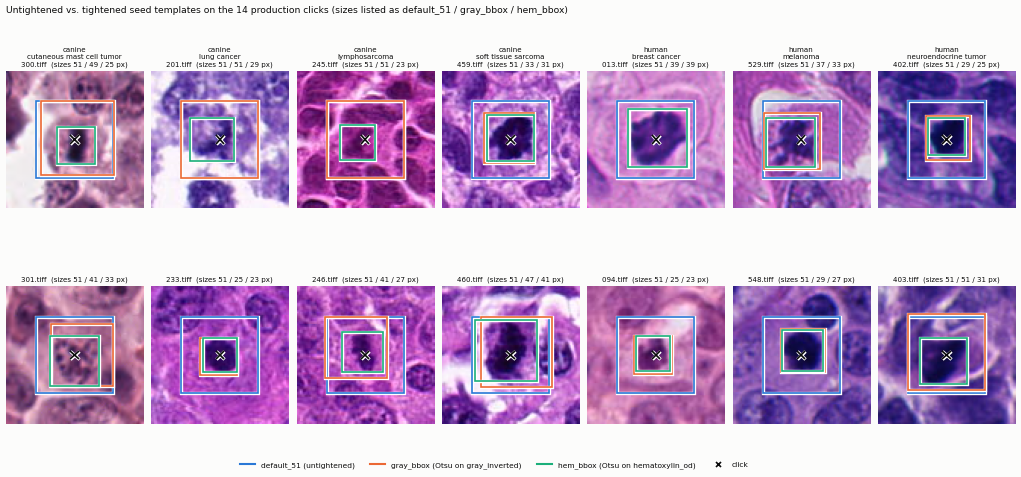

In [4]:
def draw_box(ax, row, frame_origin, color, lw=2.0):
    """
        Outline the exact pixels one template covers, in a context panel's frame.

        ax (matplotlib.axes.Axes): the context panel.
        row (dict): this condition's summary row (template_pixel_x/y, base_size).
        frame_origin (tuple[int, int]): full-image pixel at the panel's (0, 0).
        color (str): outline colour.
        lw (float): outline width.

        Returns None.
    """
    hb = row['base_size'] // 2
    x0 = row['template_pixel_x'] - hb - frame_origin[0] - 0.5
    y0 = row['template_pixel_y'] - hb - frame_origin[1] - 0.5
    ax.add_patch(plt.Rectangle((x0, y0), row['base_size'], row['base_size'], fill=False, edgecolor=color, linewidth=lw, path_effects=RING))


def draw_click(ax, roi, size=10):
    """
        Mark the click at its exact coordinate in a context panel's frame.

        ax (matplotlib.axes.Axes): the context panel.
        roi (dict): this ROI's stored record (click, frame_origin).
        size (float): marker size.

        Returns None.
    """
    ax.plot(roi['click'][0] - roi['frame_origin'][0], roi['click'][1] - roi['frame_origin'][1], marker='x', color=INK, ms=size, mew=2, path_effects=RING, linestyle='none')


domains = sorted({ROIS[fn]['domain'] for fn in ORDER})
fig, axes = plt.subplots(2, len(domains), figsize=(3.1 * len(domains), 7.9), gridspec_kw=dict(hspace=0.18, wspace=0.06))
for j, domain in enumerate(domains):
    for i, fn in enumerate([fn for fn in ORDER if ROIS[fn]['domain'] == domain]):
        ax, roi = axes[i, j], ROIS[fn]
        ax.imshow(roi['context'], extent=roi['context_extent'])
        for condition in CONDITIONS:
            draw_box(ax, roi['rows'][condition]['row'], roi['frame_origin'], COLORS[condition])
        draw_click(ax, roi)
        ax.set_xlim(-0.5, CONTEXT_WINDOW - 0.5)
        ax.set_ylim(CONTEXT_WINDOW - 0.5, -0.5)
        sizes = ' / '.join(str(roi['rows'][c]['row']['base_size']) for c in CONDITIONS)
        ax.set_title((domain.replace(' ', '\n', 1) + '\n' if i == 0 else '') + f'{fn}  (sizes {sizes} px)', fontsize=8.5)
        ax.axis('off')
handles = [plt.Line2D([], [], color=COLORS[c], lw=2.5, label=f'{c}' + (' (untightened)' if CONDITIONS[c] is None else f' (Otsu on {CONDITIONS[c]})')) for c in CONDITIONS]
handles.append(plt.Line2D([], [], color=INK, marker='x', mew=2, linestyle='none', label='click'))
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 0.0))
fig.suptitle('Untightened vs. tightened seed templates on the 14 production clicks (sizes listed as default_51 / gray_bbox / hem_bbox)', x=0.125, y=0.99, ha='left', fontsize=11)
fig.subplots_adjust(bottom=0.06, top=0.9)
fig.savefig(f'{OUT_PREFIX}_overview.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

## Step 3 -- one figure per ROI

Rows: `default_51` (untightened), `gray_bbox`, `hem_bbox`. Columns: Otsu window, Otsu binary,
components, box in context, template (RGB), template as matched (`hematoxylin_od`). Panel 6 uses one
grey scale per ROI across all three rows (0 up to the 99.5th percentile of the three templates;
brighter = more hematoxylin), so the rows' intensities are comparable. Saved as
`bbox3way_detail_<file>_<ann_id>.png`.

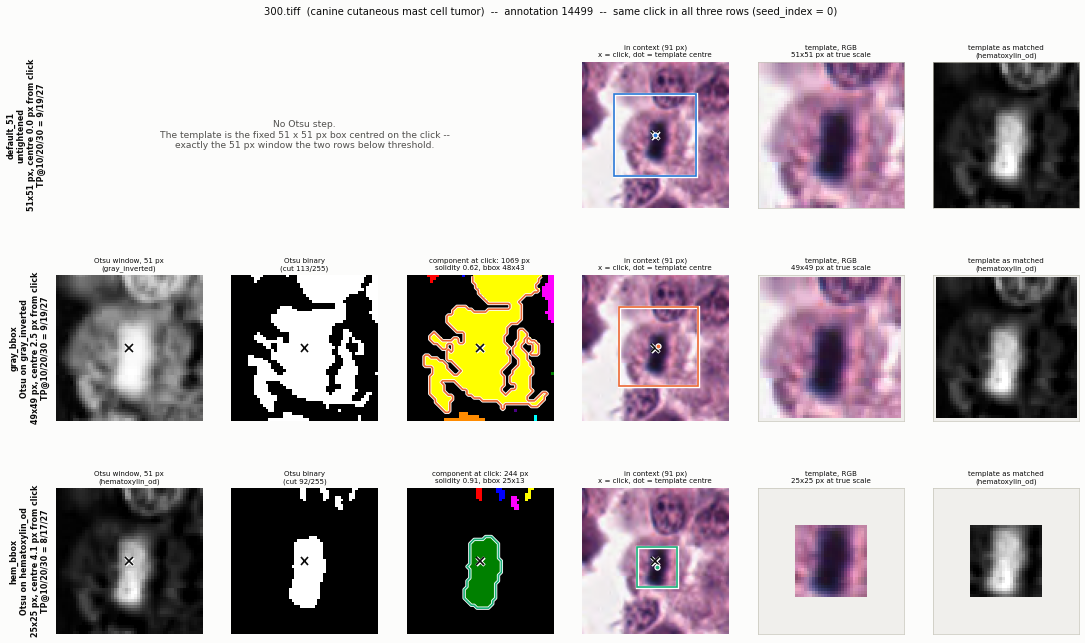

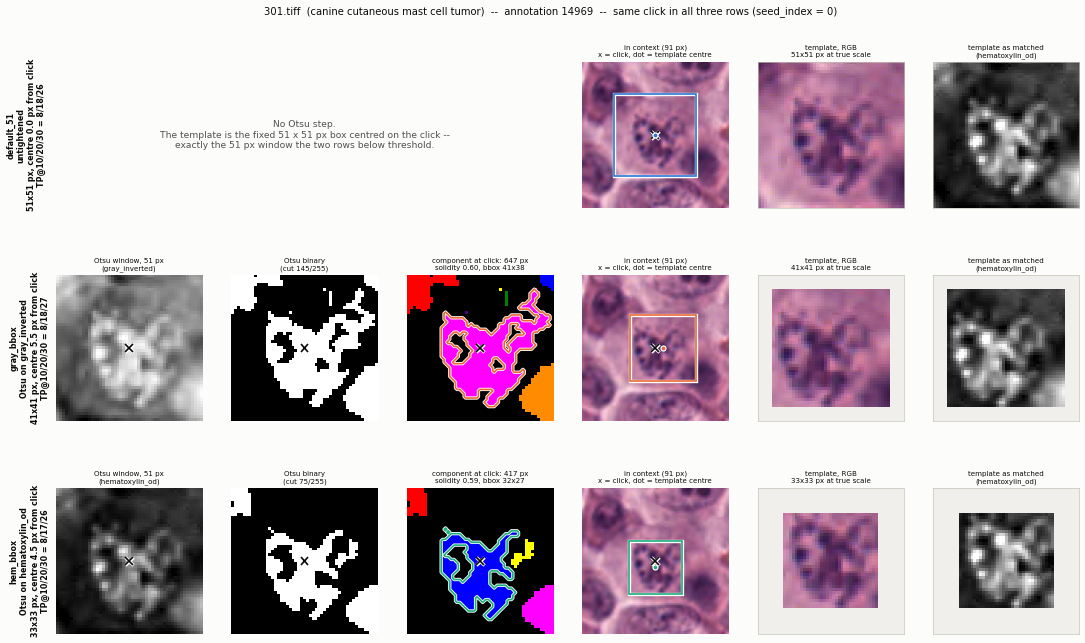

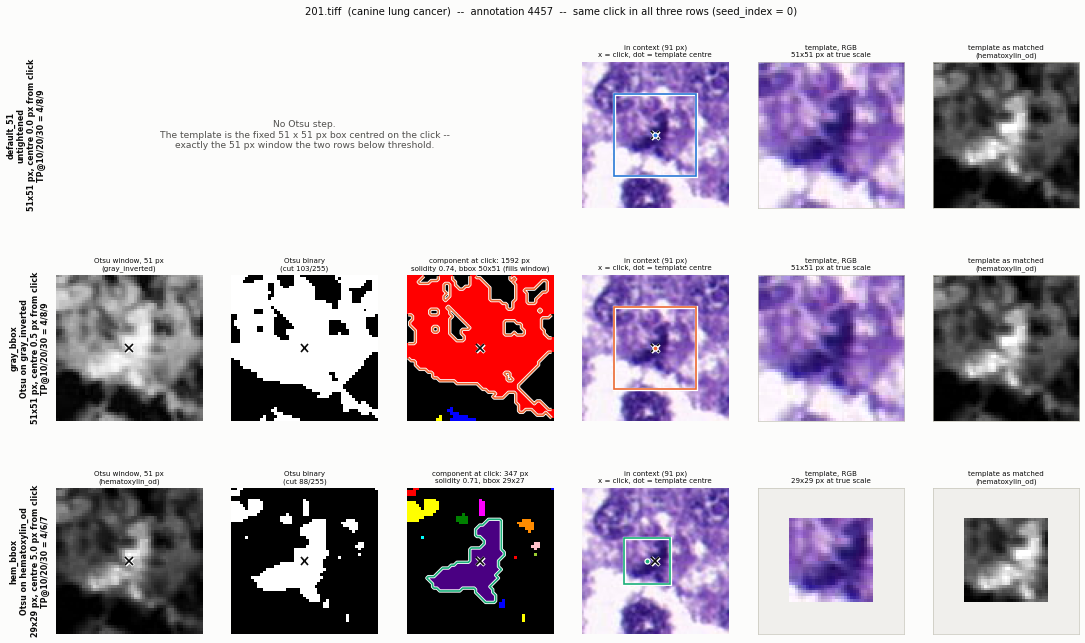

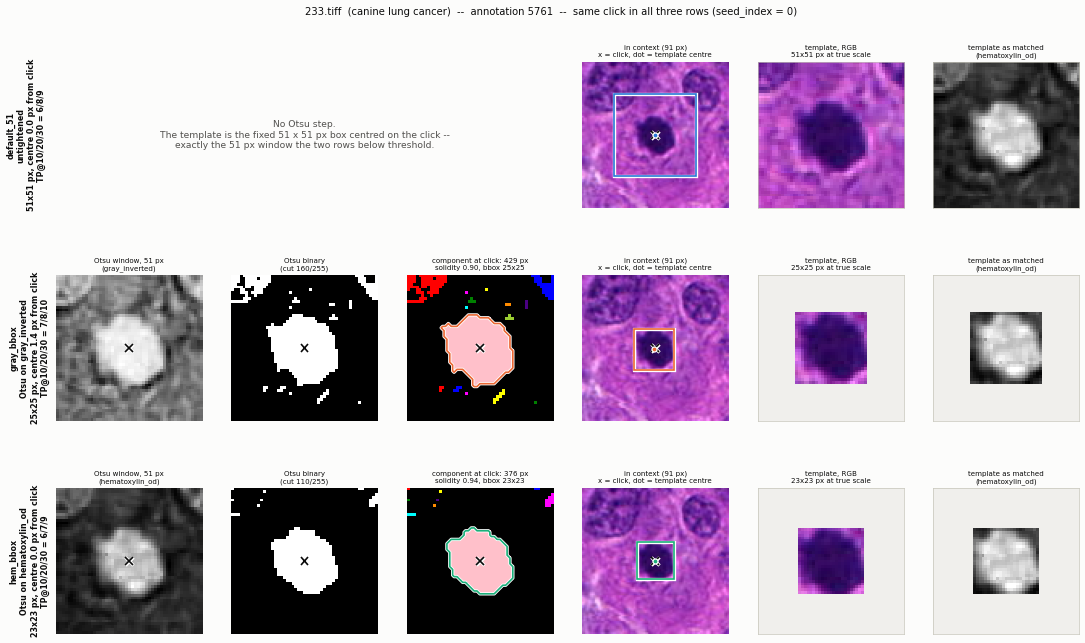

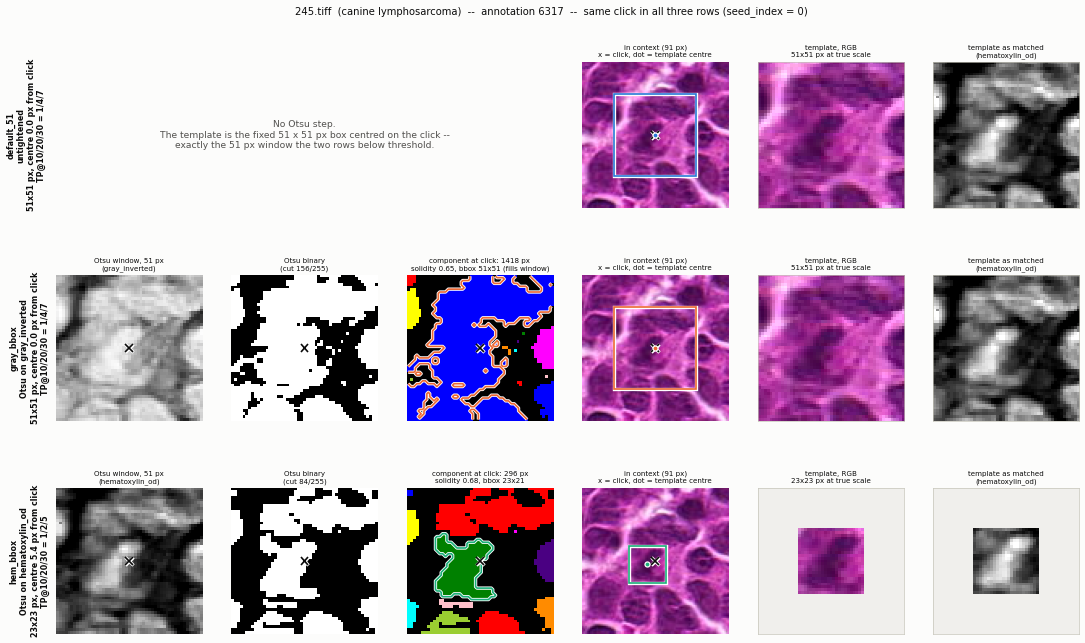

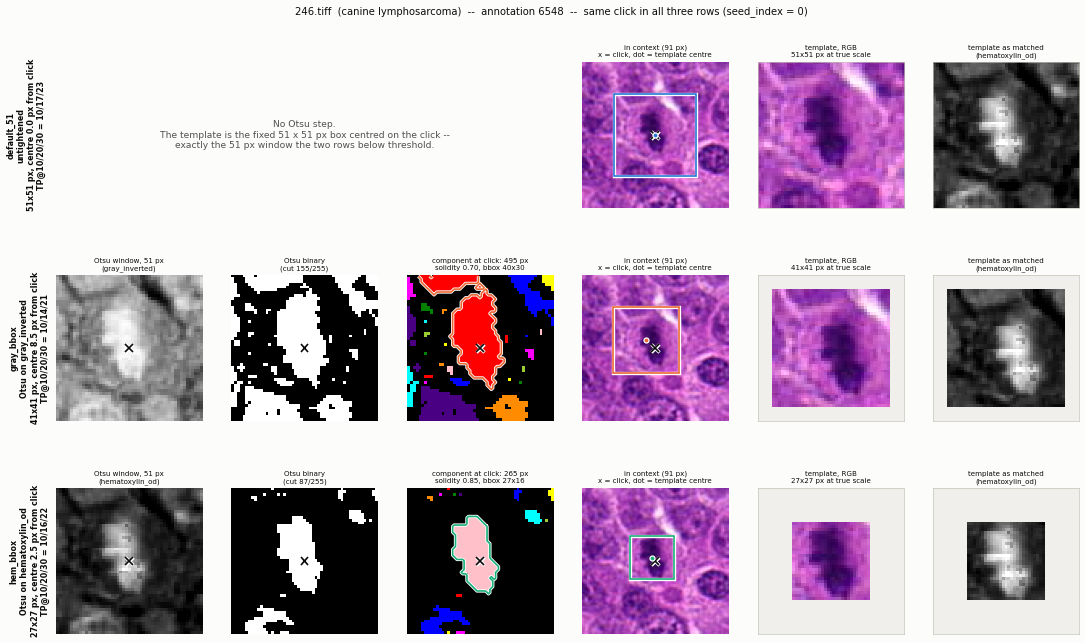

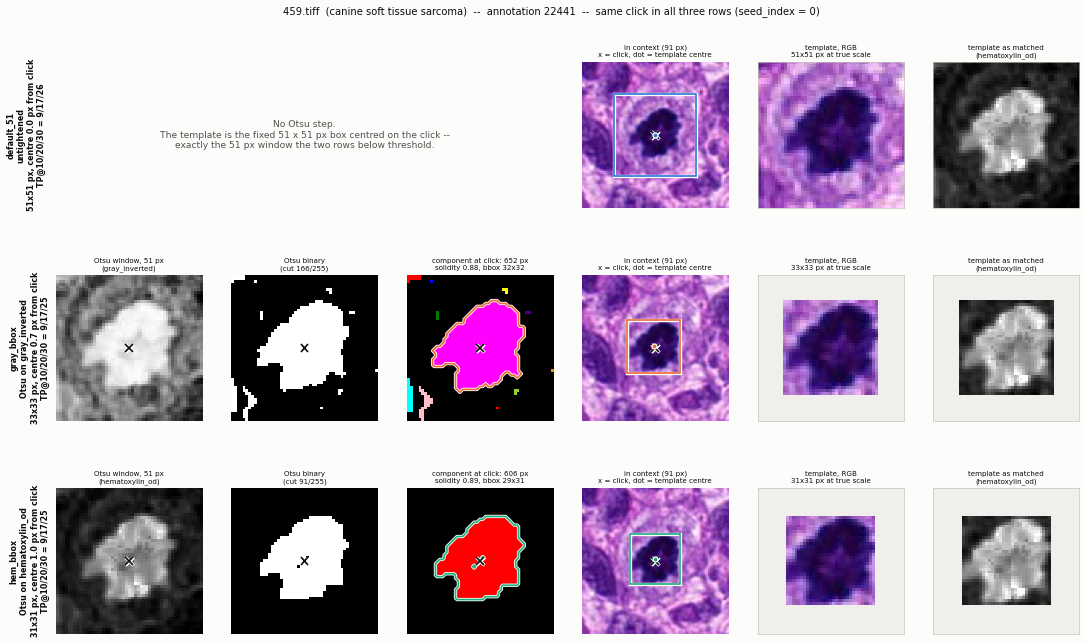

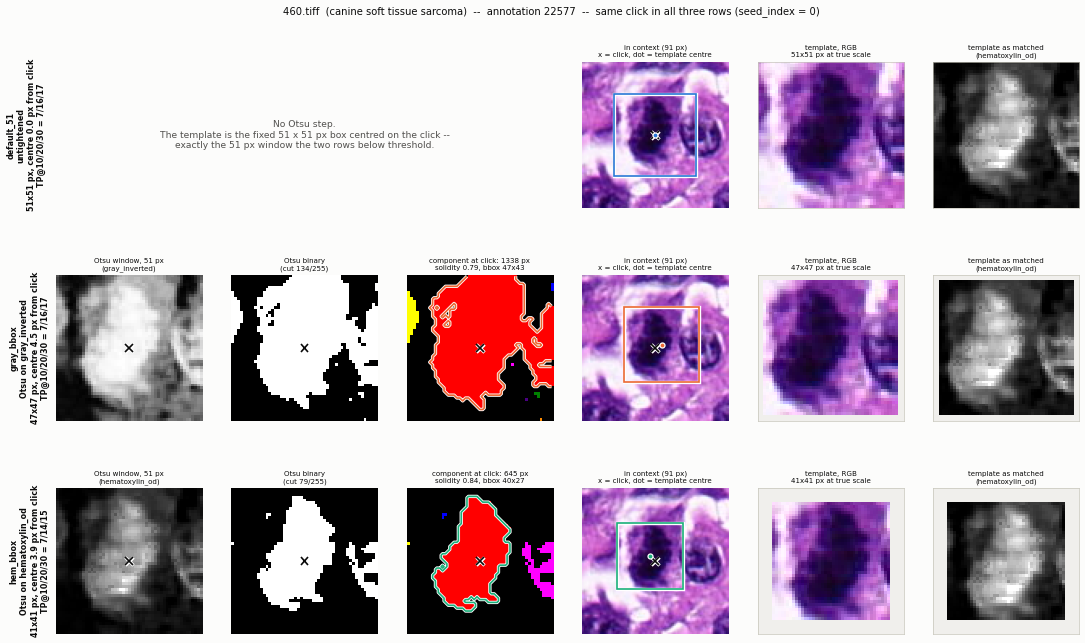

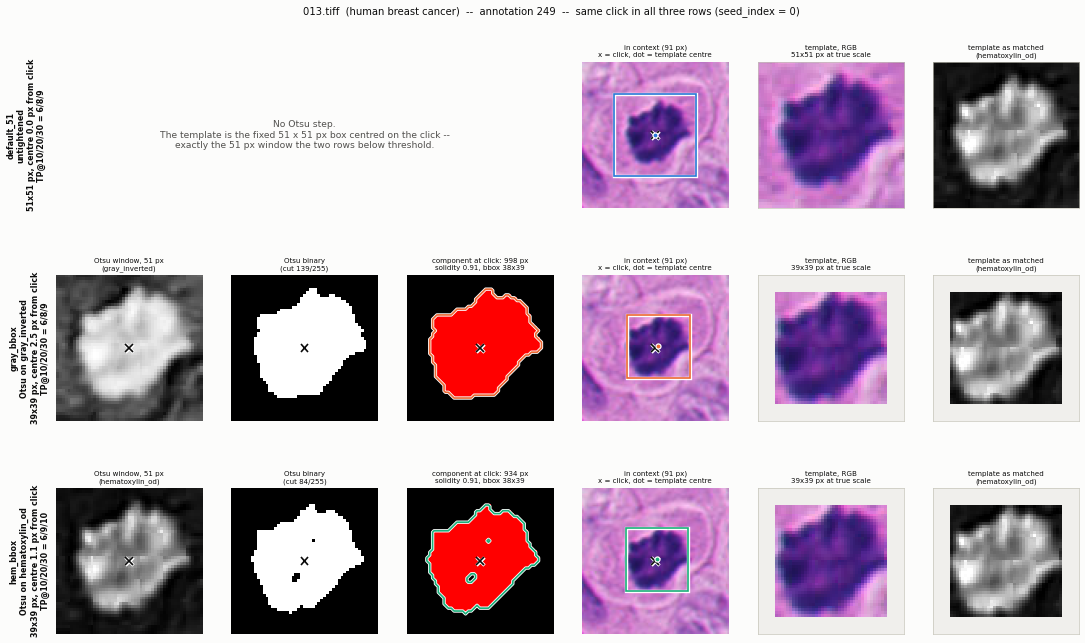

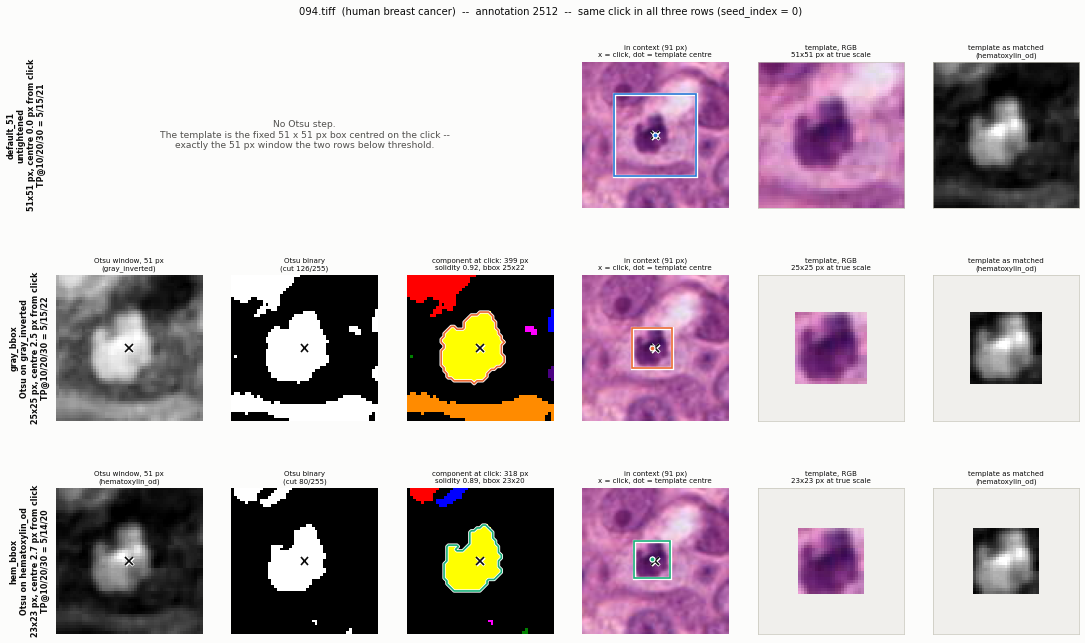

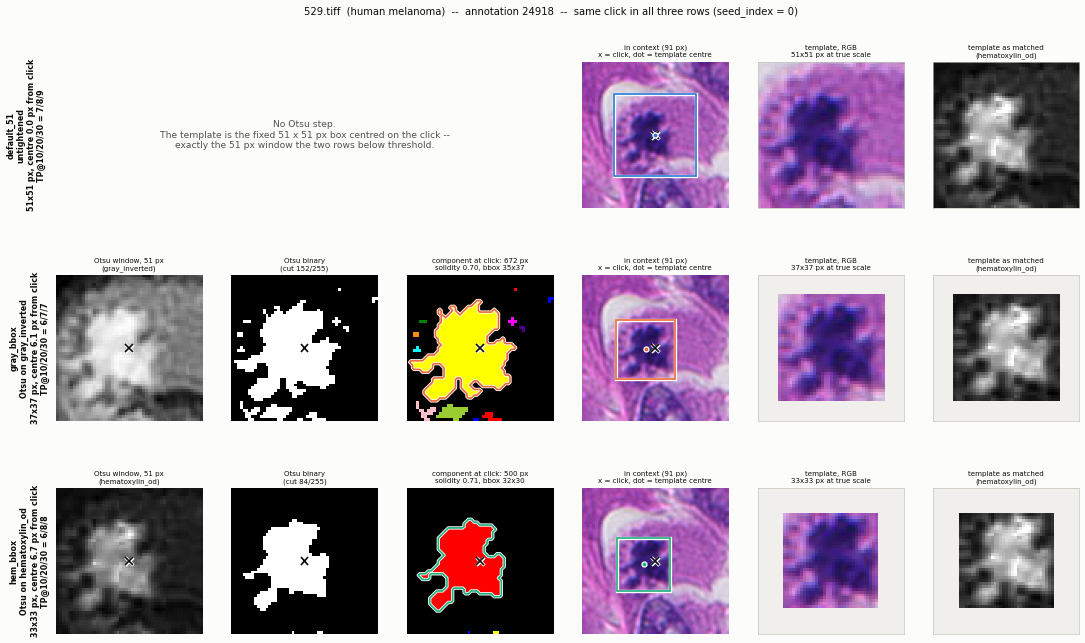

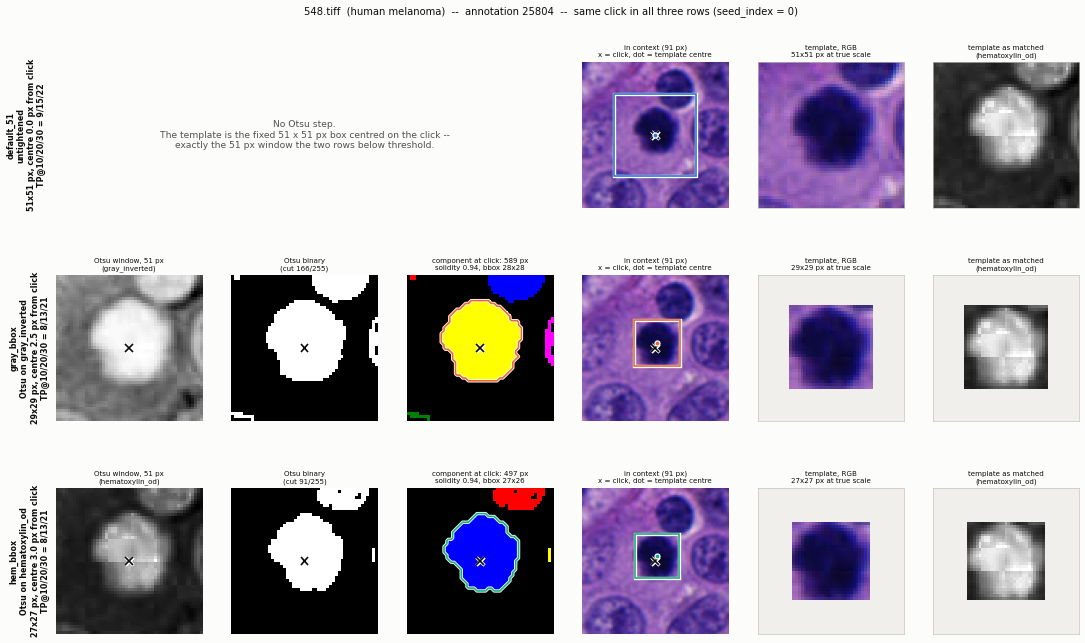

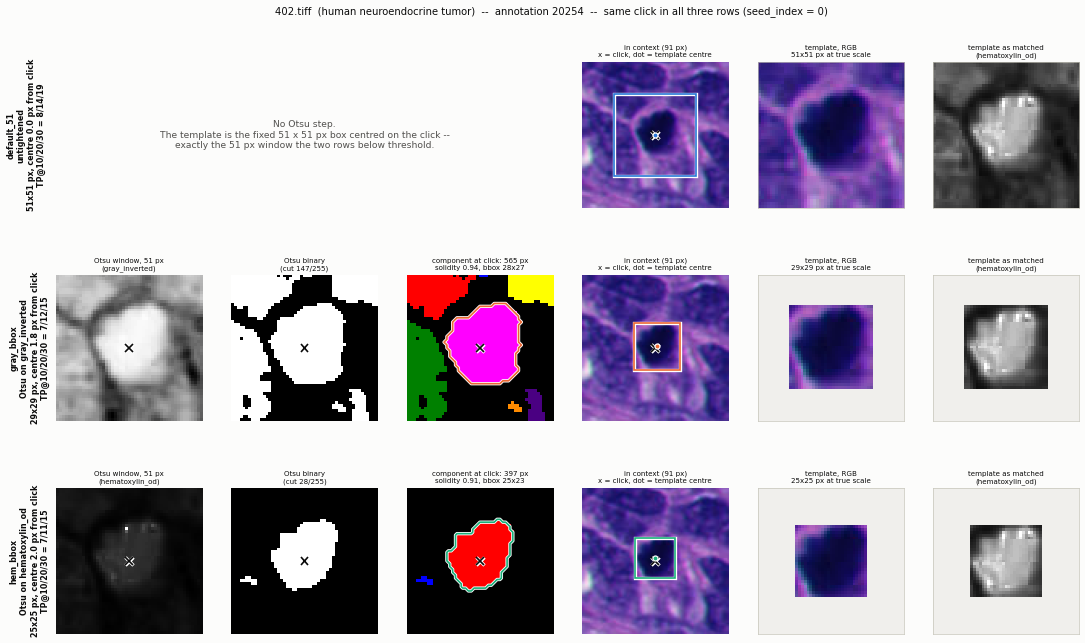

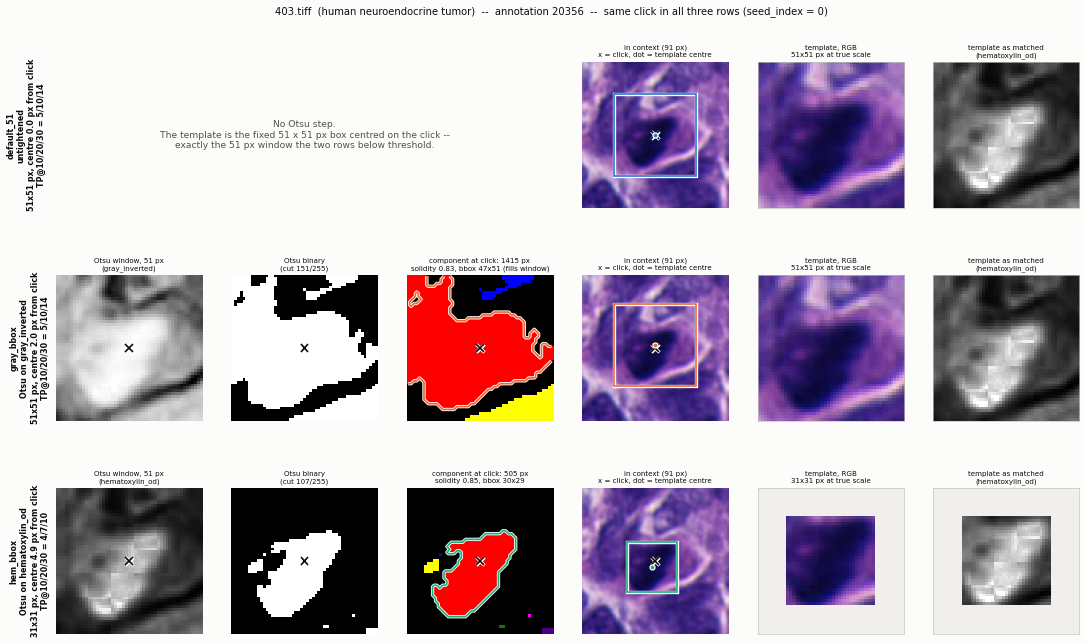

14 figures saved as bbox3way_detail_<file>_<ann_id>.png


In [5]:
def show_in_fixed_frame(ax, img, base_size, **imshow_kw):
    """
        Draw a template at true pixel scale, centred in a fixed 51 px frame.

        ax (matplotlib.axes.Axes): the panel.
        img (np.ndarray): the template, base_size x base_size (RGB or single channel).
        base_size (int): odd template side length.
        imshow_kw: passed through to imshow (cmap, vmin, vmax).

        Returns None.
    """
    hb = base_size // 2
    half = DEFAULT_BASE_SIZE // 2
    ax.set_facecolor(FRAME)
    ax.imshow(img, extent=(-hb - 0.5, hb + 0.5, hb + 0.5, -hb - 0.5), interpolation='nearest', **imshow_kw)
    ax.set_xlim(-half - 0.5, half + 0.5)
    ax.set_ylim(half + 0.5, -half - 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#c3c2b7')
        spine.set_linewidth(0.8)


def plot_roi(fn):
    """
        One ROI's three-row figure: how each template was made, and what it is.

        fn (str): ROI file name, a key of ROIS.

        Returns matplotlib.figure.Figure: the figure, already saved to disk.
    """
    roi = ROIS[fn]
    vmax = float(np.percentile(np.concatenate([roi['rows'][c]['hem_template'].ravel() for c in CONDITIONS]), 99.5))
    fig = plt.figure(figsize=(22, 12.4))
    gs = GridSpec(3, 6, figure=fig, hspace=0.45, wspace=0.2)
    mid = OTSU_WINDOW // 2
    for r, condition in enumerate(CONDITIONS):
        rec = roi['rows'][condition]
        res, row = rec['res'], rec['row']
        color = COLORS[condition]
        label_txt = f"{condition}\n{'untightened' if CONDITIONS[condition] is None else 'Otsu on ' + CONDITIONS[condition]}\n{row['base_size']}x{row['base_size']} px, centre {row['offset_from_click_px']:.1f} px from click\nTP@10/20/30 = {row['tp_at_10']}/{row['tp_at_20']}/{row['tp_at_30']}"

        if CONDITIONS[condition] is None:
            ax_text = fig.add_subplot(gs[r, 0:3])
            ax_text.axis('off')
            ax_text.text(0.5, 0.5, f'No Otsu step.\nThe template is the fixed {DEFAULT_BASE_SIZE} x {DEFAULT_BASE_SIZE} px box centred on the click --\nexactly the {OTSU_WINDOW} px window the two rows below threshold.', ha='center', va='center', fontsize=11, color=INK_2)
            ax_text.text(-0.06, 0.5, label_txt, transform=ax_text.transAxes, rotation=90, ha='center', va='center', fontsize=9.5, fontweight='bold', color=INK)
        else:
            ax_patch, ax_bin, ax_lab = (fig.add_subplot(gs[r, c]) for c in range(3))
            ax_patch.imshow(rec['otsu_window'], cmap='gray', interpolation='nearest')
            ax_patch.set_title(f'Otsu window, {OTSU_WINDOW} px\n({CONDITIONS[condition]})', fontsize=8.5)
            ax_bin.imshow(res['binary'], cmap='gray', interpolation='nearest')
            ax_bin.set_title(f"Otsu binary\n(cut {res['otsu_thresh']:.0f}/255)", fontsize=8.5)
            ax_lab.imshow(label2rgb(res['labels'], bg_label=0), interpolation='nearest')
            outline = ax_lab.contour(res['labels'] == res['center_label'], levels=[0.5], colors=[color], linewidths=2)
            outline.set_path_effects(RING)
            ax_lab.set_title(f"component at click: {row['component_area']} px\nsolidity {row['solidity']:.2f}, bbox {row['bbox_h']}x{row['bbox_w']}" + (' (fills window)' if row['fills_window'] else ''), fontsize=8.5)
            for a in (ax_patch, ax_bin, ax_lab):
                a.plot(mid, mid, marker='x', color=INK, ms=9, mew=2, path_effects=RING, linestyle='none')
                a.axis('off')
            ax_patch.text(-0.18, 0.5, label_txt, transform=ax_patch.transAxes, rotation=90, ha='center', va='center', fontsize=9.5, fontweight='bold', color=INK)

        ax_ctx = fig.add_subplot(gs[r, 3])
        ax_ctx.imshow(roi['context'], extent=roi['context_extent'])
        draw_box(ax_ctx, row, roi['frame_origin'], color)
        draw_click(ax_ctx, roi)
        ax_ctx.plot(row['template_pixel_x'] - roi['frame_origin'][0], row['template_pixel_y'] - roi['frame_origin'][1], marker='o', color=color, ms=6, mec='white', mew=1.5, linestyle='none')
        ax_ctx.set_xlim(-0.5, CONTEXT_WINDOW - 0.5)
        ax_ctx.set_ylim(CONTEXT_WINDOW - 0.5, -0.5)
        ax_ctx.set_title(f"in context ({CONTEXT_WINDOW} px)\nx = click, dot = template centre", fontsize=8.5)
        ax_ctx.axis('off')

        ax_rgb = fig.add_subplot(gs[r, 4])
        show_in_fixed_frame(ax_rgb, rec['rgb_template'], row['base_size'])
        ax_rgb.set_title(f"template, RGB\n{row['base_size']}x{row['base_size']} px at true scale", fontsize=8.5)

        ax_hem = fig.add_subplot(gs[r, 5])
        show_in_fixed_frame(ax_hem, rec['hem_template'], row['base_size'], cmap='gray', vmin=0.0, vmax=vmax)
        ax_hem.set_title('template as matched\n(hematoxylin_od)', fontsize=8.5)

    fig.suptitle(f"{fn}  ({roi['domain']})  --  annotation {roi['ann_id']}  --  same click in all three rows (seed_index = 0)", x=0.5, y=0.955, fontsize=12)
    fig.savefig(f"{OUT_PREFIX}_{fn.replace('.tiff', '')}_{roi['ann_id']}.png", dpi=120, bbox_inches='tight')
    return fig


for fn in ORDER:
    fig = plot_roi(fn)
    plt.show()
    plt.close(fig)
print(f'{len(ORDER)} figures saved as {OUT_PREFIX}_<file>_<ann_id>.png')

## Step 4 -- summary table

One row per (ROI, condition), 14 x 3 = 42. Component columns are empty for `default_51` because
it has no component.
- `fills_window`: the accepted component's bbox spans the full 51 px Otsu window on at least one
  axis, so its size is capped by the window rather than measured.
- `same_box_as_default_51`: the tightened template covers exactly the untightened box's pixels.
- `touches_window_edge`: the component reaches the border of the 51 px window, so it may continue
  outside what the gate could see.
- `component_frac_of_template`: the component's area divided by the template's area, i.e. how much
  of the template is the thresholded object.
- `template_overhang_px`: the furthest the template reaches past any edge of the 51 px window,
  in pixels (a distance). `template_px_outside_otsu_window` counts the template pixels out there
  (an area: overhang x template side).
- `tp_at_K`: copied from the measurement run for reference; nothing is recomputed here.

In [6]:
SUMMARY = pd.DataFrame(ROWS)
SUMMARY['_o'] = SUMMARY['file_name'].map({fn: i for i, fn in enumerate(ORDER)}) * 10 + SUMMARY['condition'].map({c: i for i, c in enumerate(CONDITIONS)})
SUMMARY = SUMMARY.sort_values('_o').drop(columns='_o').reset_index(drop=True)
SUMMARY.to_csv(f'{OUT_PREFIX}_summary.csv', index=False)
print(f'-> {OUT_PREFIX}_summary.csv  ({len(SUMMARY)} rows = 14 ROIs x {len(CONDITIONS)} conditions)')

tight = SUMMARY[SUMMARY['condition'] != 'default_51']
for c in ('gray_bbox', 'hem_bbox'):
    s = SUMMARY[SUMMARY['condition'] == c]
    print(f"{c:9s}: smaller than 51 px on {int((s['base_size'] < DEFAULT_BASE_SIZE).sum())}/14, same box as default_51 on {int(s['same_box_as_default_51'].sum())}/14, component fills the window on {int(s['fills_window'].sum())}/14, median component {s['component_area'].median():.0f} px ({s['component_frac_of_window'].median():.0%} of the window), template pokes outside the window on {int((s['template_px_outside_otsu_window'] > 0).sum())}/14")
print(f"whole accepted component inside its template: {int(tight['component_inside_template'].sum())}/{len(tight)}")
for c in ('gray_bbox', 'hem_bbox'):
    s = SUMMARY[SUMMARY['condition'] == c]
    print(f"{c:9s}: component touches the window edge on {int(s['touches_window_edge'].sum())}/14 {s.loc[s['touches_window_edge'], 'file_name'].tolist()}; median solidity {s['solidity'].median():.2f}; component covers a median {s['component_frac_of_template'].median():.0%} of its template")
sizes = SUMMARY.pivot(index='file_name', columns='condition', values='base_size')
gap = (sizes['gray_bbox'] - sizes['hem_bbox']).sort_values()
outside = tight[tight['template_px_outside_otsu_window'] > 0]
print(f"templates reaching past the 51 px window (file, condition, overhang px, pixels outside): {[(r.file_name, r.condition, r.template_overhang_px, r.template_px_outside_otsu_window) for r in outside.itertuples()]}")
print(f"gray_bbox - hem_bbox size gap: <= 4 px on {int((gap <= 4).sum())}/14 {gap[gap <= 4].index.tolist()}; 5-13 px on {int(gap.between(5, 13).sum())} {gap[gap.between(5, 13)].index.tolist()}; >= 14 px on {int((gap >= 14).sum())} {gap[gap >= 14].index.tolist()}")

cols = ['domain', 'ann_id', 'condition', 'base_size', 'offset_from_click_px', 'component_area', 'component_frac_of_template', 'solidity', 'bbox_h', 'bbox_w', 'fills_window', 'touches_window_edge', 'same_box_as_default_51', 'template_overhang_px', 'template_px_outside_otsu_window', 'tp_at_10', 'tp_at_20', 'tp_at_30']
SUMMARY.set_index('file_name')[cols]

-> bbox3way_detail_summary.csv  (42 rows = 14 ROIs x 3 conditions)
gray_bbox: smaller than 51 px on 11/14, same box as default_51 on 2/14, component fills the window on 3/14, median component 662 px (25% of the window), template pokes outside the window on 4/14
hem_bbox : smaller than 51 px on 14/14, same box as default_51 on 0/14, component fills the window on 0/14, median component 407 px (16% of the window), template pokes outside the window on 0/14
whole accepted component inside its template: 28/28
gray_bbox: component touches the window edge on 6/14 ['300.tiff', '201.tiff', '245.tiff', '246.tiff', '460.tiff', '403.tiff']; median solidity 0.81; component covers a median 60% of its template
hem_bbox : component touches the window edge on 0/14 []; median solidity 0.87; component covers a median 54% of its template
templates reaching past the 51 px window (file, condition, overhang px, pixels outside): [('300.tiff', 'gray_bbox', 1, 49), ('246.tiff', 'gray_bbox', 1, 41), ('460.tiff', 

,domain,ann_id,condition,base_size,offset_from_click_px,component_area,component_frac_of_template,solidity,bbox_h,bbox_w,fills_window,touches_window_edge,same_box_as_default_51,template_overhang_px,template_px_outside_otsu_window,tp_at_10,tp_at_20,tp_at_30
file_name,,,,,,,,,,,,,,,,,,
300.tiff,canine cutaneous mast cell tumor,14499,default_51,51,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,0,9,19,27
300.tiff,canine cutaneous mast cell tumor,14499,gray_bbox,49,2.500,1069.0,0.445,0.619,48.0,43.0,False,True,False,1,49,9,19,27
300.tiff,canine cutaneous mast cell tumor,14499,hem_bbox,25,4.123,244.0,0.390,0.910,25.0,13.0,False,False,False,0,0,8,17,27
301.tiff,canine cutaneous mast cell tumor,14969,default_51,51,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,0,8,18,26
301.tiff,canine cutaneous mast cell tumor,14969,gray_bbox,41,5.500,647.0,0.385,0.601,41.0,38.0,False,False,False,0,0,8,18,27
301.tiff,canine cutaneous mast cell tumor,14969,hem_bbox,33,4.500,417.0,0.383,0.589,32.0,27.0,False,False,False,0,0,8,17,26
201.tiff,canine lung cancer,4457,default_51,51,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,0,0,4,8,9
201.tiff,canine lung cancer,4457,gray_bbox,51,0.500,1592.0,0.612,0.744,50.0,51.0,True,True,True,0,0,4,8,9
201.tiff,canine lung cancer,4457,hem_bbox,29,5.000,347.0,0.413,0.714,29.0,27.0,False,False,False,0,0,4,6,7


## Closing summary

**Every picture above is checked against the real run.** All 10 check types pass: the 14 clicks,
42 box sizes and offsets match the measurement notebook's CSV, the 28 Otsu boxes match
`ss.tighten_box_otsu` / `ss.tightened_template_box`, and all 42 `hematoxylin_od` templates in
panel 6 are pixel-identical to what the production search correlates. The untightened box is
confirmed, on all 14 ROIs, to be the same 51 px window both Otsu gates threshold.

**What the untightened box is.** Always 51 x 51 px on the click, so it contains the clicked nucleus
plus its surroundings. In the overview, neighbouring nuclei or cell borders fall inside it on most
ROIs (e.g. `245.tiff`, `246.tiff`, `300.tiff`, `460.tiff`). Both tightened boxes are cut from inside
that same window.

**What the two tightened boxes are, and where they differ.** From the Step 4 table:
- `hem_bbox` is smaller than 51 px on 14/14 ROIs, and its component never reaches the edge of the
  51 px window (0/14). `gray_bbox` is smaller than 51 px on 11/14, and its component reaches the
  window edge on 6/14 (`201`, `245`, `246`, `300`, `403`, `460`).
- **On 7/14 ROIs the two Otsu boxes nearly agree** (sizes within 4 px: `013`, `094`, `233`, `402`,
  `459`, `529`, `548`). In the overview both sit on the same compact dark nucleus.
- **On 5/14 they differ by 14 px or more** (`201`, `245`, `246`, `300`, `403`). On all five, the
  `gray_inverted` component runs into the window edge, while the `hematoxylin_od` component stays on
  the dark nucleus. Panel 3 of those figures shows the gray component spreading into the region
  around the nucleus: a large irregular region on `245` and `300`, an extension to the top of the
  window on `246`. On `201` and `245` the gray box is the full 51 px window again, and on `245` it
  is the same pixels as the untightened box.
- **Recentring can push a template 1-2 px past the window the gate saw.** On 4 ROIs the
  `gray_bbox` template overhangs one edge of the 51 px window: 1 px on `246` and `300`, 2 px on
  `403` and `460`. That is one or two edge rows/columns of real image the Otsu step never looked at
  (41-102 template pixels). No `hem_bbox` template does this. The geometry: the template is a
  square whose side is the component bbox's *longer* side, centred on the bbox. Along the bbox's
  *shorter* side it is therefore wider than the component by `base_size - short side`, split evenly
  either side. When the component sits closer to a window edge than that half-slack, the square
  crosses the edge. For example, `403`'s component is 47 rows x 51 columns and starts at row 0; the
  51 px square adds 2 rows each side, so it starts at row -2. Nothing in D8 or
  `tightened_template_box` keeps the template inside the window; D8 guarantees only that the whole
  component is inside the template. The 1-2 px seen here is not a bound. A thin component lying
  along a window edge could overhang by up to about half the window.
- **Tightened templates are still roughly half background.** The accepted component covers a
  median 60% (gray) and 54% (hem) of its own template. D8's guarantee holds on all 28: the whole
  component is inside its template.

**What this notebook does not claim.** The `TP@10/20/30` values in the row labels are copied from
the measurement run so each picture can be read next to its outcome. Nothing here tests *why*
precision differs between conditions. "Template contains more surrounding context" and "template
is the chromatin core" are descriptions of what the boxes look like, not measured causes, and a
single click per ROI can't separate them from which nucleus happened to be clicked.